In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
df = pd.read_csv('/content/data.csv', low_memory=False, encoding='latin1')

data = pd.to_numeric(df['no2'], errors='coerce')
x = data.dropna().values

a_r = 0.5 * (102303655 % 7)
b_r = 0.3 * ((102303655 % 5) + 1)

print("a_r:", a_r)
print("b_r:", b_r)

z = x + a_r * np.sin(b_r * x)
z = z.reshape(-1, 1)

a_r: 3.0
b_r: 0.3


In [19]:
scaler = StandardScaler()
z_scaled = scaler.fit_transform(z)

z_tensor = torch.tensor(z_scaled, dtype=torch.float32).to(device)

batch_size = 64
dataloader = torch.utils.data.DataLoader(
    z_tensor, batch_size=batch_size, shuffle=True
)

In [22]:
latent_dim = 5
lr = 0.001
num_epochs = 150

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

generator = Generator().to(device)
discriminator = Discriminator().to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

criterion = nn.BCELoss()

In [23]:
loss_G_history = []
loss_D_history = []

print("Training started...")

for epoch in range(num_epochs):
    for real_samples in dataloader:

        curr_batch_size = real_samples.size(0)

        real_labels = torch.ones(curr_batch_size, 1).to(device)
        fake_labels = torch.zeros(curr_batch_size, 1).to(device)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        outputs_real = discriminator(real_samples)
        loss_real = criterion(outputs_real, real_labels)

        noise = torch.randn(curr_batch_size, latent_dim).to(device)
        fake_samples = generator(noise)

        outputs_fake = discriminator(fake_samples.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        optimizer_G.zero_grad()

        outputs_gen = discriminator(fake_samples)
        loss_G = criterion(outputs_gen, real_labels)

        loss_G.backward()
        optimizer_G.step()

    loss_G_history.append(loss_G.item())
    loss_D_history.append(loss_D.item())

    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

Training started...
Epoch [20/150] | D: 1.3879 | G: 0.6927
Epoch [40/150] | D: 1.3863 | G: 0.6926
Epoch [60/150] | D: 1.3825 | G: 0.6773
Epoch [80/150] | D: 1.3834 | G: 0.6896
Epoch [100/150] | D: 1.3874 | G: 0.7216
Epoch [120/150] | D: 1.3863 | G: 0.6941
Epoch [140/150] | D: 1.3807 | G: 0.6962


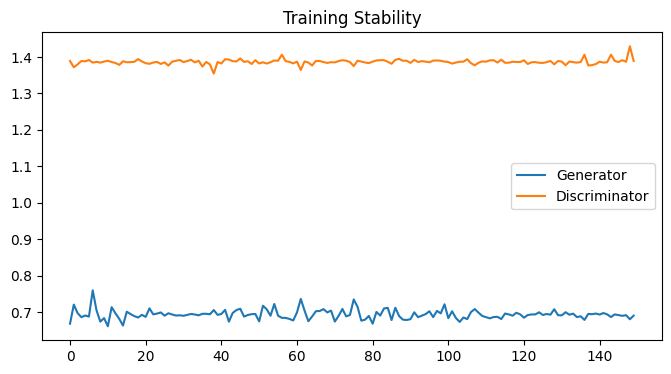

In [24]:
plt.figure(figsize=(8,4))
plt.plot(loss_G_history, label='Generator')
plt.plot(loss_D_history, label='Discriminator')
plt.legend()
plt.title("Training Stability")
plt.show()

In [25]:
num_samples = 10000

with torch.no_grad():
    noise = torch.randn(num_samples, latent_dim).to(device)
    generated_scaled = generator(noise).cpu().numpy()

generated_data = scaler.inverse_transform(generated_scaled)

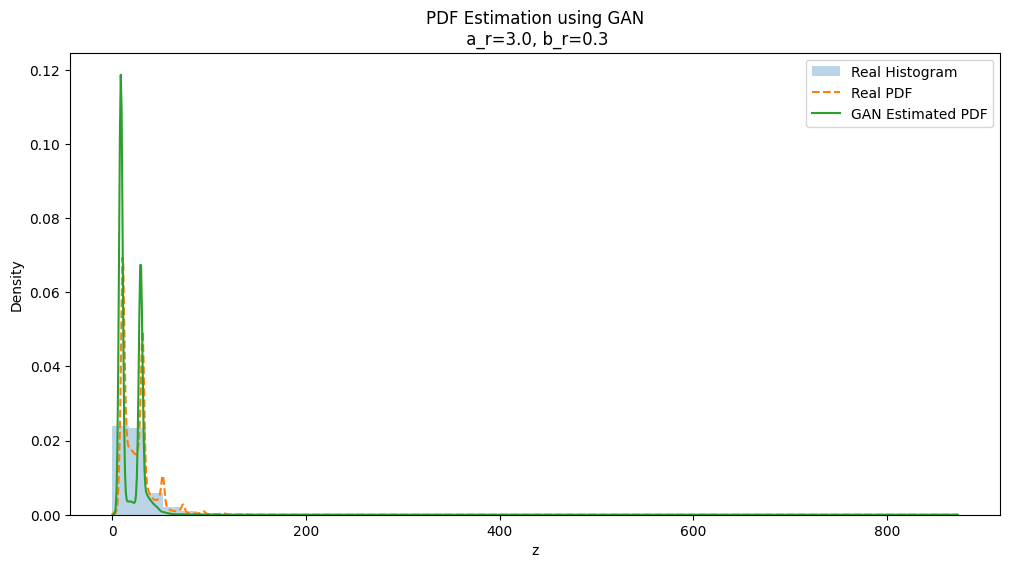

In [ ]:
kde_real = gaussian_kde(z.flatten())
kde_gen = gaussian_kde(generated_data.flatten())

x_grid = np.linspace(
    min(z.min(), generated_data.min()),
    max(z.max(), generated_data.max()),
    1000
)

plt.figure(figsize=(12,6))

plt.hist(z, bins=50, density=True, alpha=0.3, label='Real Histogram')
plt.plot(x_grid, kde_real(x_grid), '--', label='Real PDF')
plt.plot(x_grid, kde_gen(x_grid), label='GAN Estimated PDF')
plt.xlim(z.min(), 200)

plt.title(f'PDF Estimation using GAN\n a_r={a_r}, b_r={b_r}')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.show()

In [27]:
print("Mean:", z.mean().item())
print("Std:", z.std().item())
print("Min:", z.min().item())
print("Max:", z.max().item())

Mean: 25.706855143625948
Std: 18.639077033235413
Min: 0.0
Max: 873.334889691228
